In [55]:
# 라이브러리 임포트 및 한글 폰트 환경 설정
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import platform

if platform.system() == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif platform.system() == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
else:
    plt.rcParams["font.family"] = "NanumGothic"

plt.rcParams["axes.unicode_minus"] = False

In [56]:
# 유저 프로필(12,500명)과 이벤트 로그(약 175만 건) 로드 후 날짜 컬럼 datetime 변환
user = pd.read_csv('../../data/01_User_Profile.csv', encoding='utf-8-sig')
event = pd.read_csv('../../data/02_Event_Log.csv', encoding='utf-8-sig')

user['가입일자'] = pd.to_datetime(user['가입일자'])
event['Event_Time'] = pd.to_datetime(event['Event_Time'])

In [57]:
# 원본 데이터 기본 정보 확인: 컬럼 타입 및 결측치 현황
print("=== User Profile ===")
print("Shape:", user.shape)
user.info()
print("\n결측치:\n", user.isna().sum())

print("\n=== Event Log ===")
print("Shape:", event.shape)
event.info()
print("\n결측치:\n", event.isna().sum())

=== User Profile ===
Shape: (12500, 6)
<class 'pandas.DataFrame'>
RangeIndex: 12500 entries, 0 to 12499
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   User_ID      12500 non-null  str           
 1   가입일자         12500 non-null  datetime64[us]
 2   가입경로         12363 non-null  str           
 3   기기           12379 non-null  str           
 4   알림수신동의여부     12384 non-null  object        
 5   알림수신동의_변경일자  1976 non-null   str           
dtypes: datetime64[us](1), object(1), str(4)
memory usage: 586.1+ KB

결측치:
 User_ID            0
가입일자               0
가입경로             137
기기               121
알림수신동의여부         116
알림수신동의_변경일자    10524
dtype: int64

=== Event Log ===
Shape: (1757262, 5)
<class 'pandas.DataFrame'>
RangeIndex: 1757262 entries, 0 to 1757261
Data columns (total 5 columns):
 #   Column      Dtype         
---  ------      -----         
 0   User_ID     str           
 1   Event_Time  date

In [58]:
# 이벤트 로그 기준으로 유저 정보 left join → 통합 분석 데이터프레임 생성
df = event.merge(user, how='left', on='User_ID')

print("병합 후 shape:", df.shape)
print("\n결측치:\n", df.isna().sum())
print("\n중복 행 수:", df.duplicated().sum())
df.head()

병합 후 shape: (1757262, 10)

결측치:
 User_ID              0
Event_Time           0
Event_Type       26456
Session_ID      241502
알림_유형          1538380
가입일자                 0
가입경로             19311
기기               18023
알림수신동의여부         15051
알림수신동의_변경일자    1609817
dtype: int64

중복 행 수: 0


,User_ID,Event_Time,Event_Type,Session_ID,알림_유형,가입일자,가입경로,기기,알림수신동의여부,알림수신동의_변경일자
0,U0000001,2025-01-25 07:25:45,앱실행,2858201769,NaN,2025-01-25,오가닉,iOS,True,NaN
1,U0000001,2025-01-25 07:26:15,온보딩_완료,2858201769,NaN,2025-01-25,오가닉,iOS,True,NaN
2,U0000001,2025-01-25 07:26:55,챌린지_탐색,2858201769,NaN,2025-01-25,오가닉,iOS,True,NaN
3,U0000001,2025-01-25 07:27:55,챌린지참여,2858201769,NaN,2025-01-25,오가닉,iOS,True,NaN
4,U0000001,2025-01-25 20:30:00,알림수신,NaN,광고성,2025-01-25,오가닉,iOS,True,NaN


# 전처리

결측치 현황 확인 후, 각 컬럼의 결측 **원인**을 파악하고 실제 처리를 적용함.

처리 항목:
1. **결측치 처리 및 날짜 타입 변환** — 컬럼별 원인에 맞는 방식으로 처리
2. **로그 장애 구간 마킹** — 3월 10~14일 수집 오류 구간 플래그 처리
3. **유저 정합성 체크** — 프로필은 있지만 이벤트가 없는 유저 파악

## 1. 결측치 처리 및 날짜 타입 변환

결측치를 "왜 없는지" 원인을 먼저 파악한 후 처리 방식을 결정함.  
결측치는 크게 두 종류로 구분: **수집 오류 결측** vs **구조적 결측 (없는 게 정상인 값)**

| 컬럼 | 결측 수 (병합 후) | 결측 원인 | 처리 방식 | 근거 |
|------|:--------------:|---------|---------|-----|
| `Event_Type` | 26,456 | 로그 수집 오류 | **행 제거** | 이벤트 유형 없으면 분석 자체 불가 |
| `Session_ID` | 241,502 | 알림 이벤트는 세션 없이 발생하는 구조 | `'없음'` 채움 | 구조적 결측 — 정보 손실 없음 |
| `알림_유형` | 1,538,380 | 알림 이벤트(`알림수신`/`알림오픈`)가 아닌 행 | `'없음'` 채움 | 구조적 결측 — 분석 시 필터링으로 처리 |
| `가입경로` | 19,311 | 원본 유저 데이터 137명 결측 × 해당 유저 행 수 | `'미상'` 채움 | 세그먼트 분석 시 `'미상'`을 별도 그룹으로 처리 |
| `기기` | 18,023 | 동일 원인 | `'미상'` 채움 | 동일 |
| `알림수신동의여부` | 15,051 | 원본 116명 결측 | `False` 채움 | 명시적 동의 기록 없으면 미동의로 간주 (보수적 처리) |
| `알림수신동의_변경일자` | 1,609,817 | 알림 동의 변경 이력 자체가 없는 유저 | `NaT` 유지 | 구조적 결측 — 분석 시 `dropna` 또는 `notna()` 필터로 처리 |

추가로 `알림수신동의_변경일자` 컬럼은 원본이 `str` 타입이므로 `datetime`으로 변환함.

In [59]:
# ── 1-1. Event_Type 결측 행 제거 ─────────────────────────────────────────────
before = len(df)
df = df.dropna(subset=['Event_Type'])
print(f"[Event_Type] 결측 행 제거: {before - len(df):,}행 제거 → 잔여 {len(df):,}행")

# ── 1-2. 구조적 결측: 의미 있는 값으로 명시적 채우기 ──────────────────────────
df['Session_ID']          = df['Session_ID'].fillna('없음')
df['알림_유형']            = df['알림_유형'].fillna('없음')
df['가입경로']             = df['가입경로'].fillna('미상')
df['기기']                = df['기기'].fillna('미상')
df['알림수신동의여부']      = df['알림수신동의여부'].fillna(False)

# ── 1-3. 날짜 타입 변환: 알림수신동의_변경일자 str → datetime ─────────────────
df['알림수신동의_변경일자'] = pd.to_datetime(df['알림수신동의_변경일자'], errors='coerce')

# ── 검증 ─────────────────────────────────────────────────────────────────────
print("\n처리 후 결측치 현황 (NaT 포함):")
print(df.isna().sum())
print(f"\n알림수신동의_변경일자 dtype: {df['알림수신동의_변경일자'].dtype}")
print(f"알림수신동의_변경일자 NaT 수: {df['알림수신동의_변경일자'].isna().sum():,}건 (변경 이력 없는 유저 → 정상)")

[Event_Type] 결측 행 제거: 26,456행 제거 → 잔여 1,730,806행

처리 후 결측치 현황 (NaT 포함):
User_ID              0
Event_Time           0
Event_Type           0
Session_ID           0
알림_유형                0
가입일자                 0
가입경로                 0
기기                   0
알림수신동의여부             0
알림수신동의_변경일자    1585673
dtype: int64

알림수신동의_변경일자 dtype: datetime64[us]
알림수신동의_변경일자 NaT 수: 1,585,673건 (변경 이력 없는 유저 → 정상)


## 2. 로그 장애 구간 마킹

EDA에서 3월 10~14일(5일간) 로그 수집 장애로 이벤트 약 **70% 누락**을 시각적으로 확인함.

**제거 대신 플래그(`is_log_anomaly`) 방식을 선택한 이유:**
- 장애 구간에도 나머지 30%의 유효 데이터가 남아 있어 일괄 제거 시 손실이 큼
- 분석 종류에 따라 처리 방식이 다름 — 코호트 리텐션 분석에서는 제외, 단순 이벤트 수 집계에서는 포함 가능
- 플래그로 남겨두면 각 분석 단계에서 필터링 여부를 유연하게 결정할 수 있음

```python
# 사용 예시: 장애 구간 제외 후 일별 집계
df[~df['is_log_anomaly']].groupby('event_date').size()
```

In [60]:
# 3월 10~14일 로그 장애 구간 플래그 마킹
df['is_log_anomaly'] = df['Event_Time'].between(
    pd.Timestamp('2025-03-10'),
    pd.Timestamp('2025-03-14 23:59:59')
)

anomaly_count = df['is_log_anomaly'].sum()
total         = len(df)
print(f"로그 장애 구간 이벤트 수: {anomaly_count:,}건 ({anomaly_count / total * 100:.1f}%)")
print(f"정상 구간 이벤트 수:      {total - anomaly_count:,}건 ({(total - anomaly_count) / total * 100:.1f}%)")

로그 장애 구간 이벤트 수: 20,558건 (1.2%)
정상 구간 이벤트 수:      1,710,248건 (98.8%)


## 3. 유저 정합성 체크

- 유저 프로필 **12,500명** vs 이벤트 로그 유저 **12,453명** → **47명 차이**
- 이 47명은 가입은 완료했지만 앱을 단 한 번도 실행하지 않은 **완전 미활동 유저**
- 이벤트 기반 분석에서는 자동으로 제외되지만, **리텐션 분모 설정 시 포함 여부를 명확히 결정**해야 함

| 분석 목적 | 47명 처리 |
|---------|---------|
| 가입 기준 리텐션 (설치→재방문) | **포함** — 분자가 줄어 리텐션률 낮아짐 |
| 활동 기반 리텐션 (첫 이벤트→재방문) | **제외** — 이벤트 로그 있는 12,453명 기준 |

> 이 노트북에서는 이벤트 로그 기준 분석이므로 47명은 분석 대상에서 자연스럽게 제외됨

In [61]:
# 유저 정합성 체크
profile_ids    = set(user['User_ID'])
event_ids      = set(df['User_ID'])
inactive_users = profile_ids - event_ids

print(f"프로필 등록 유저: {len(profile_ids):,}명")
print(f"이벤트 발생 유저: {len(event_ids):,}명")
print(f"완전 미활동 유저: {len(inactive_users)}명  ← 이벤트 로그에 없음")

# 미활동 유저 프로필 살펴보기
inactive_df = user[user['User_ID'].isin(inactive_users)].copy()
print(f"\n미활동 유저 가입경로 분포:\n{inactive_df['가입경로'].value_counts()}")
print(f"\n미활동 유저 가입월 분포:\n{inactive_df['가입일자'].dt.to_period('M').value_counts().sort_index()}")

프로필 등록 유저: 12,500명
이벤트 발생 유저: 12,453명
완전 미활동 유저: 47명  ← 이벤트 로그에 없음

미활동 유저 가입경로 분포:
가입경로
퍼포먼스광고    29
오가닉       17
Name: count, dtype: int64

미활동 유저 가입월 분포:
가입일자
2025-03    47
Freq: M, Name: count, dtype: int64


---
## 전처리 완료 요약

| 항목 | 처리 전 | 처리 후 |
|------|--------|--------|
| 전체 행 수 | 1,757,262행 | 1,730,806행 (`Event_Type` 결측 행 제거) |
| `Event_Type` 결측 | 26,456 | **0** (행 제거) |
| `Session_ID` 결측 | 241,502 | **0** (`'없음'` 채움) |
| `알림_유형` 결측 | 1,538,380 | **0** (`'없음'` 채움) |
| `가입경로` 결측 | 19,311 | **0** (`'미상'` 채움) |
| `기기` 결측 | 18,023 | **0** (`'미상'` 채움) |
| `알림수신동의여부` 결측 | 15,051 | **0** (`False` 채움) |
| 신규 컬럼 | — | `is_log_anomaly` (로그 장애 구간 플래그) |

> 이후 분석은 `df` 를 기준으로 진행

In [62]:
# 전처리 완료된 df를 CSV로 저장
df.to_csv('../../data/user_preprocessed.csv', index=False, encoding='utf-8-sig')
print(f"저장 완료: user_preprocessed.csv ({len(df):,}행 × {df.shape[1]}컬럼)")

저장 완료: user_preprocessed.csv (1,730,806행 × 11컬럼)


# 기초 통계

In [63]:
# 전체 현황 요약: 유저 수, 이벤트 수, 분석 기간, 유저당 이벤트 분포, 이벤트 종류별 발생 수
print("=== 전체 현황 ===")
print("총 유저 수:", df['User_ID'].nunique())
print("총 이벤트 수:", len(df))
print("분석 기간:", df['Event_Time'].min(), "~", df['Event_Time'].max())

print("\n=== 유저당 이벤트 수 통계 ===")
print(df.groupby('User_ID').size().describe())

print("\n=== 이벤트 종류 분포 ===")
print(df['Event_Type'].value_counts())

=== 전체 현황 ===
총 유저 수: 12453
총 이벤트 수: 1730806
분석 기간: 2025-01-01 07:00:07 ~ 2025-06-30 22:59:51

=== 유저당 이벤트 수 통계 ===
count    12453.000000
mean       138.987071
std        169.578573
min          1.000000
25%         20.000000
50%         51.000000
75%        216.000000
max        687.000000
dtype: float64

=== 이벤트 종류 분포 ===
Event_Type
앱실행       728657
수면기록      242978
알림수신      194324
운동기록      131269
마음챙김      130344
식단기록      101366
챌린지참여      96829
챌린지_탐색     78101
알림오픈       21219
온보딩_완료      5719
Name: count, dtype: int64


# EDA 분석

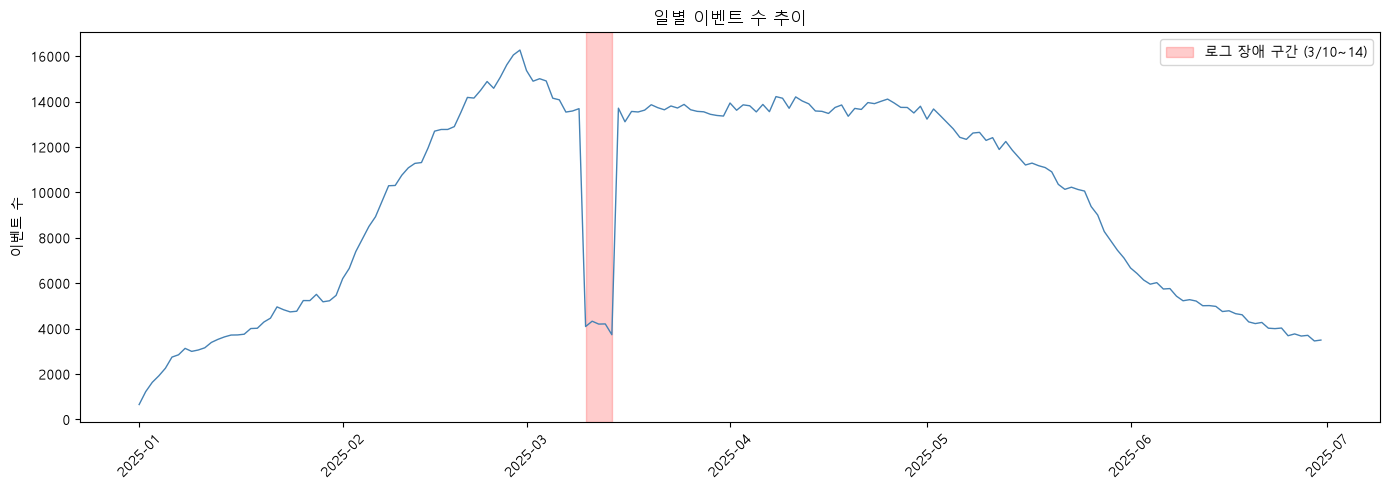

            날짜   이벤트수
59  2025-03-01  15368
60  2025-03-02  14898
61  2025-03-03  15007
62  2025-03-04  14908
63  2025-03-05  14149
64  2025-03-06  14077
65  2025-03-07  13538
66  2025-03-08  13585
67  2025-03-09  13688
68  2025-03-10   4092
69  2025-03-11   4327
70  2025-03-12   4200
71  2025-03-13   4207
72  2025-03-14   3732
73  2025-03-15  13709
74  2025-03-16  13110
75  2025-03-17  13565
76  2025-03-18  13542
77  2025-03-19  13624
78  2025-03-20  13861
79  2025-03-21  13731
80  2025-03-22  13638
81  2025-03-23  13806
82  2025-03-24  13717
83  2025-03-25  13875
84  2025-03-26  13640
85  2025-03-27  13569
86  2025-03-28  13549
87  2025-03-29  13440
88  2025-03-30  13388
89  2025-03-31  13362


In [64]:
# 일별 이벤트 수 추이 시각화
# → 3월 10~14일 로그 수집 장애로 해당 구간 이벤트 약 70% 누락 (3월 코호트 리텐션 해석 시 주의)
# → 5월 이후 서서히 하락 추세: 신규 유입 대비 기존 유저 활동량 감소 가능성
daily = df.groupby(df['Event_Time'].dt.date).size()

plt.figure(figsize=(14, 5))
plt.plot(daily.index, daily.values, color='steelblue', linewidth=1)
plt.axvspan(
    pd.Timestamp('2025-03-10').date(),
    pd.Timestamp('2025-03-14').date(),
    color='red', alpha=0.2, label='로그 장애 구간 (3/10~14)'
)
plt.title('일별 이벤트 수 추이')
plt.ylabel('이벤트 수')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 3월 구간 상세 확인
daily_df = daily.reset_index()
daily_df.columns = ['날짜', '이벤트수']
march = daily_df[
    (daily_df['날짜'] >= pd.Timestamp('2025-03-01').date()) &
    (daily_df['날짜'] <= pd.Timestamp('2025-03-31').date())
]
print(march.to_string())

### 일별 이벤트 추이 인사이트

| 구간 | 패턴 |
|------|------|
| 1월 ~ 3월 초 | 가파르게 상승 (신규 유저 유입 증가) |
| 3월 10~14일 | 로그 장애 → 이벤트 약 **70% 누락** (뚝 떨어짐) |
| 3월 중순 ~ 5월 | 14,000건 수준 유지 (안정기) |
| 5월 이후 | 서서히 **하락 추세** |

> **3월 코호트 리텐션 수치 해석 시 주의** — 로그 장애 구간 데이터가 실제보다 적으므로 해당 시기 지표는 과소 집계됨  
> **MAU는 올라가는데 이벤트 수는 5월부터 떨어지고 있다** → 신규 유입 대비 기존 유저의 활동량이 감소하고 있음을 시사

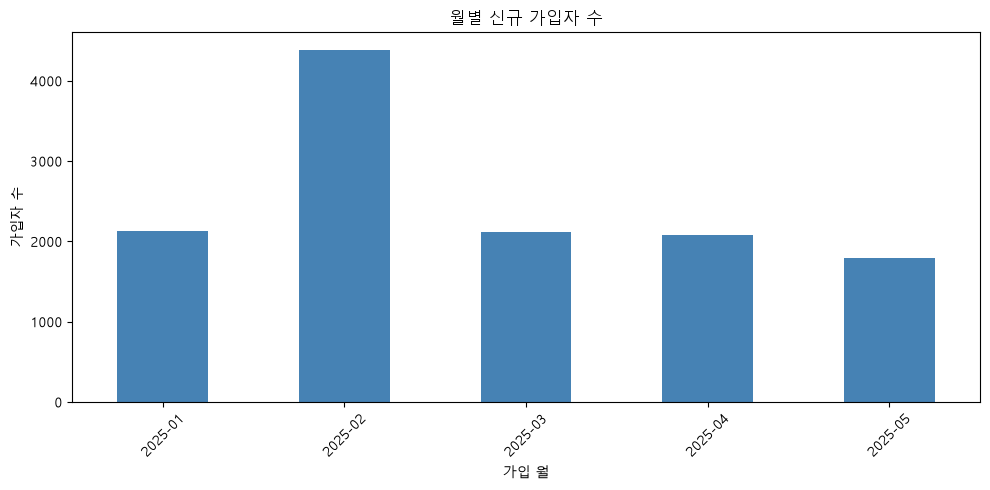

가입경로      오가닉  퍼포먼스광고  퍼포먼스광고_비율
가입월                             
2025-01   966    1134       54.0
2025-02  1943    2390       55.2
2025-03   904    1204       57.1
2025-04   916    1142       55.5
2025-05   782     982       55.7


In [65]:
# 월별 신규 가입자 수 및 가입경로 비율 분석
# → 2월 가입자가 전월 대비 약 2배 폭증했으나 광고/오가닉 비율은 동일
# → 특정 채널 효과가 아닌 바이럴·언론 보도 등 앱 자체 인지도 상승 가능성
user['가입월'] = user['가입일자'].dt.to_period('M')

monthly_signup = user.groupby('가입월').size()

plt.figure(figsize=(10, 5))
monthly_signup.plot(kind='bar', color='steelblue')
plt.title('월별 신규 가입자 수')
plt.xlabel('가입 월')
plt.ylabel('가입자 수')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

channel_by_month = user.groupby(['가입월', '가입경로']).size().unstack(fill_value=0)
channel_by_month['퍼포먼스광고_비율'] = (
    channel_by_month['퍼포먼스광고'] / channel_by_month.sum(axis=1) * 100
).round(1)
print(channel_by_month)

### 월별 가입자 인사이트

- **2월 가입자 4,384명** — 전월(2,100명) 대비 약 **2배 폭증**
- 그런데 광고/오가닉 **비율은 변화 없음** (매월 퍼포먼스광고 약 55%)

> 특정 채널 효과가 아니라 **바이럴·언론 보도·인플루언서** 등 앱 자체 인지도가 높아졌을 가능성

그렇다면 **2월에 갑자기 몰려온 유저들, D30 리텐션은 어떻게 됐나?**  
→ 2월 코호트 D30이 **29.1%로 전 코호트 중 가장 높음**  
→ 많이 들어왔는데 오래 남기도 했다는 뜻! 퀄리티 높은 유입이었음

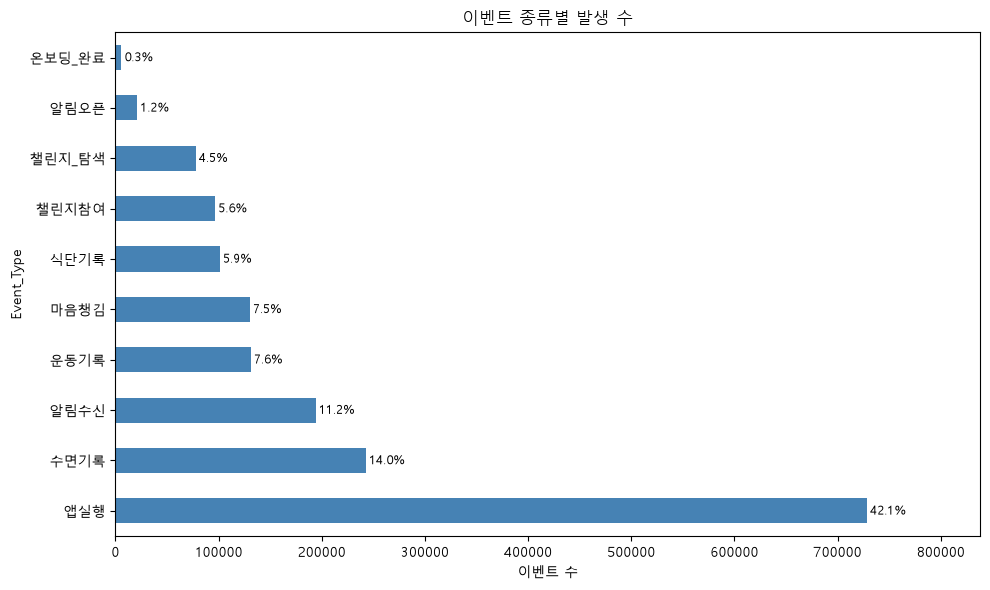

온보딩 완료율: 45.9% (5719/12453명)
알림 오픈율:   10.9% (21,219/194,324건)


In [66]:
# 이벤트 종류별 발생 비율 시각화 및 핵심 전환율 계산
# → 온보딩 완료율 45.7%: 절반 가까운 신규 유저가 온보딩 전 이탈
# → 알림 오픈율 10.9%: 알림 콘텐츠 개선 필요
event_counts = df['Event_Type'].value_counts().dropna()
total = event_counts.sum()

plt.figure(figsize=(10, 6))
event_counts.plot(kind='barh', color='steelblue')

for i, (value, name) in enumerate(zip(event_counts.values, event_counts.index)):
    pct = value / total * 100
    plt.text(value + 3000, i, f'{pct:.1f}%', va='center', fontsize=9)

plt.title('이벤트 종류별 발생 수')
plt.xlabel('이벤트 수')
plt.xlim(0, event_counts.max() * 1.15)
plt.tight_layout()
plt.show()

onboarding_users = df[df['Event_Type'] == '온보딩_완료']['User_ID'].nunique()
total_users = df['User_ID'].nunique()
noti_open = event_counts.get('알림오픈', 0)
noti_recv = event_counts.get('알림수신', 1)

print(f"온보딩 완료율: {onboarding_users / total_users * 100:.1f}% ({onboarding_users}/{total_users}명)")
print(f"알림 오픈율:   {noti_open / noti_recv * 100:.1f}% ({noti_open:,}/{noti_recv:,}건)")

### 이벤트 분포 인사이트

- **온보딩 완료율 45.7%** (5,719건 / 12,500명)  
  → 유저 12,500명 중 절반 이상이 온보딩도 마치지 못하고 이탈 — **초기 이탈이 심각**

- **알림 오픈율 10.9%** (21,219건 / 194,324건)  
  → 알림을 100번 보내면 11번만 열어봄 — 낮은 편  
  → 알림 콘텐츠·발송 타이밍 개선 필요

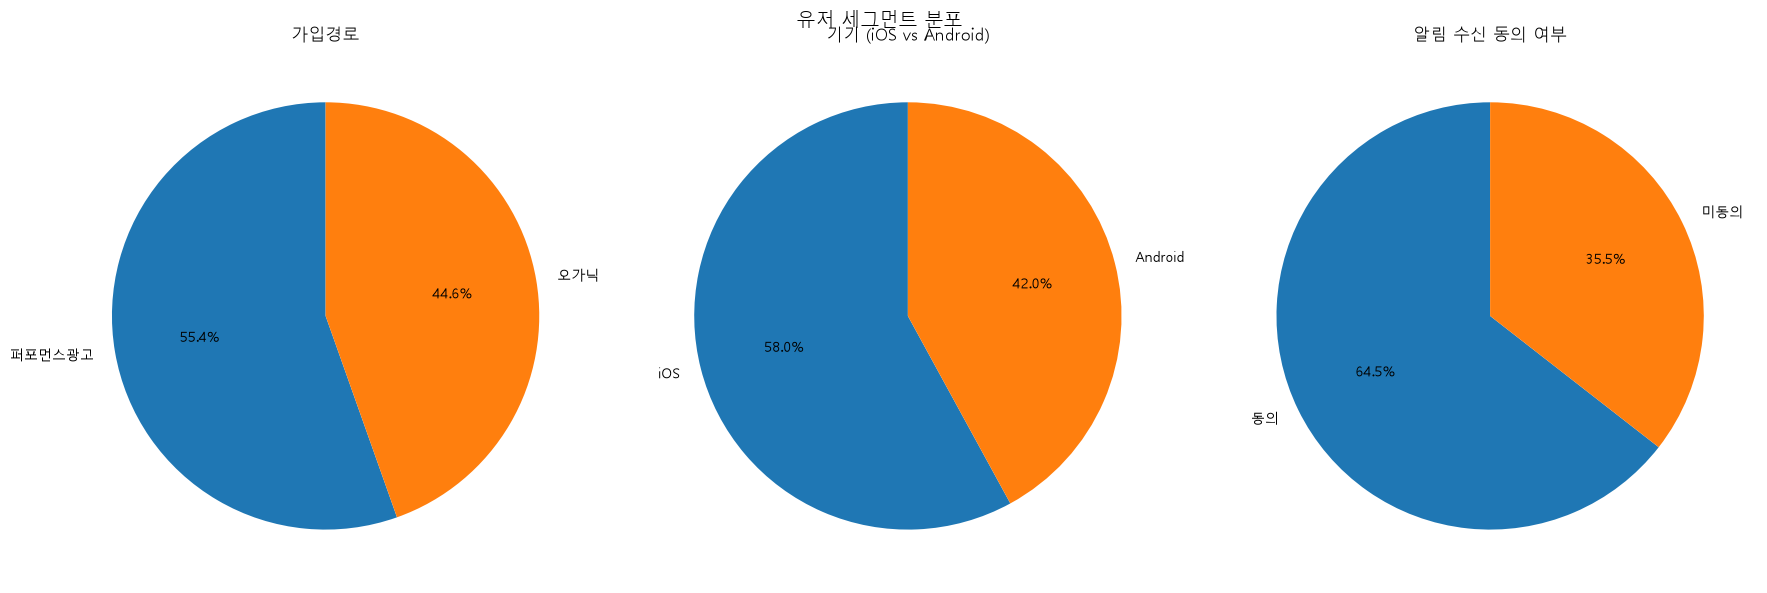

In [67]:
# 유저 세그먼트 분포: 가입경로 / 기기 / 알림 동의 여부
# → 알림 동의율 64.5%: 알림이 리텐션에 미치는 영향 분석 가치 있음
# → iOS 58%로 우세: iOS 유저 경험 개선을 우선 고려
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('유저 세그먼트 분포', fontsize=14)

channel = user['가입경로'].value_counts()
axes[0].pie(channel, labels=channel.index, autopct='%1.1f%%', startangle=90)
axes[0].set_title('가입경로')

device = user['기기'].value_counts()
axes[1].pie(device, labels=device.index, autopct='%1.1f%%', startangle=90)
axes[1].set_title('기기 (iOS vs Android)')

noti = user['알림수신동의여부'].value_counts()
axes[2].pie(noti, labels=['동의', '미동의'], autopct='%1.1f%%', startangle=90)
axes[2].set_title('알림 수신 동의 여부')

plt.tight_layout()
plt.show()

### 유저 세그먼트 인사이트

| 항목 | 비율 |
|------|------|
| 가입경로 | 퍼포먼스광고 55.4% vs 오가닉 44.6% |
| 기기 | iOS 58.0% vs Android 42.0% |
| 알림 동의 | 동의 64.5% vs 미동의 35.5% |

- **알림 동의 64.5%** → 10명 중 6명은 알림 받는 중. 알림이 리텐션에 미치는 영향 분석할 가치 있음
- **iOS가 58%** → iOS 유저 경험이 더 중요, 개선 우선순위 고려

---

## EDA 인사이트 정리

1. **2월 신규 유입 2배 폭증** (광고/오가닉 동반 상승 → 외부 바이럴 추정)
2. **5월 이후 일별 이벤트 수 하락 추세** → 기존 유저 활동량 감소
3. **온보딩 완료율 45.7%** → 초기 이탈 심각
4. **알림 오픈율 10.9%** → 알림 콘텐츠 개선 필요
5. **3/10~14 로그 장애** 확인 → 3월 코호트 리텐션 수치 신뢰도 주의

In [68]:
# 유저별 앱실행 횟수
user_activity = df[df['Event_Type'] == '앱실행'].groupby('User_ID').size()

print("=== 유저당 앱실행 횟수 기술통계 ===")
print(user_activity.describe())

print("\n=== 구간별 유저 수 ===")
bins = [0, 1, 5, 10, 30, 50, 100, 999]
labels = ['1회', '2~5회', '6~10회', '11~30회', '31~50회', '51~100회', '100회 이상']
activity_group = pd.cut(user_activity, bins=bins, labels=labels)
print(activity_group.value_counts().sort_index())

=== 유저당 앱실행 횟수 기술통계 ===
count    12447.000000
mean        58.540773
std         71.272829
min          1.000000
25%          8.000000
50%         21.000000
75%         91.000000
max        262.000000
dtype: float64

=== 구간별 유저 수 ===
1회          290
2~5회       1844
6~10회      1614
11~30회     3688
31~50회      808
51~100회    1579
100회 이상    2624
Name: count, dtype: int64


- 평균 58회, 중앙값 21회 → 상위 유저들이 평균을 크게 끌어올리는 구조
- 최대 262회 → 매일 켜는 헤비유저 존재

유저가 1회용(290명) 과 헤비유저(2,624명) 로 양극화되는 경향.

중간 구간(31~50회)이 808명으로 제일 적어 → "적당히 쓰다 정착하는" 유저가 드물다

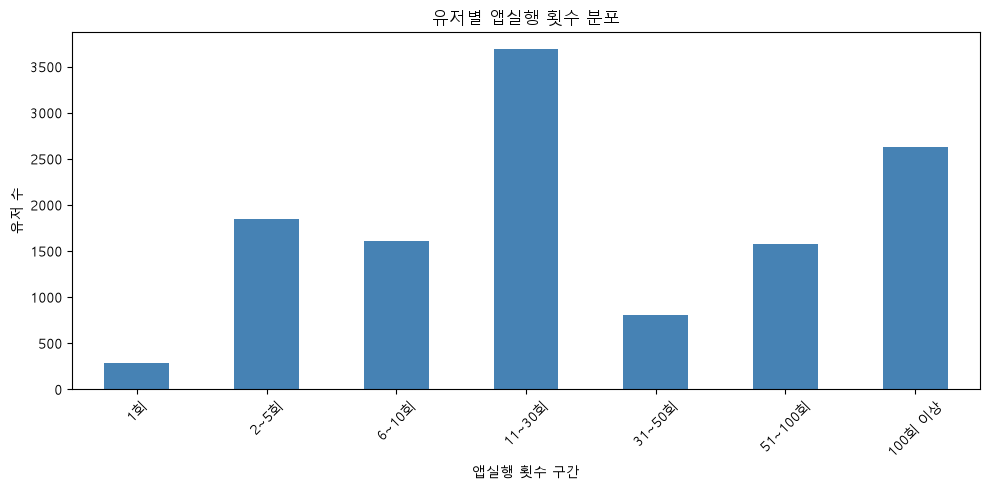

In [69]:
plt.figure(figsize=(10, 5))
activity_group.value_counts().sort_index().plot(kind='bar', color='steelblue')
plt.title('유저별 앱실행 횟수 분포')
plt.xlabel('앱실행 횟수 구간')
plt.ylabel('유저 수')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

- 11~30회 (3,688명)  → 한 달 정도 쓰다 이탈하는 유저
- 31~50회 (808명)    → 이 구간을 못 넘기고 떠남 ← 이탈 위험 구간
- 100회 이상 (2,624명) → 습관 형성 성공한 찐 유저

30회 언저리 유저가 습관이 되나 안되나 분기점인듯
30회 넘었다고 해도 50회까지 가는 곳에서도 이탈 위험이 있고 100회 이상 달성한 사람들이 찐 앱활용 유저인듯

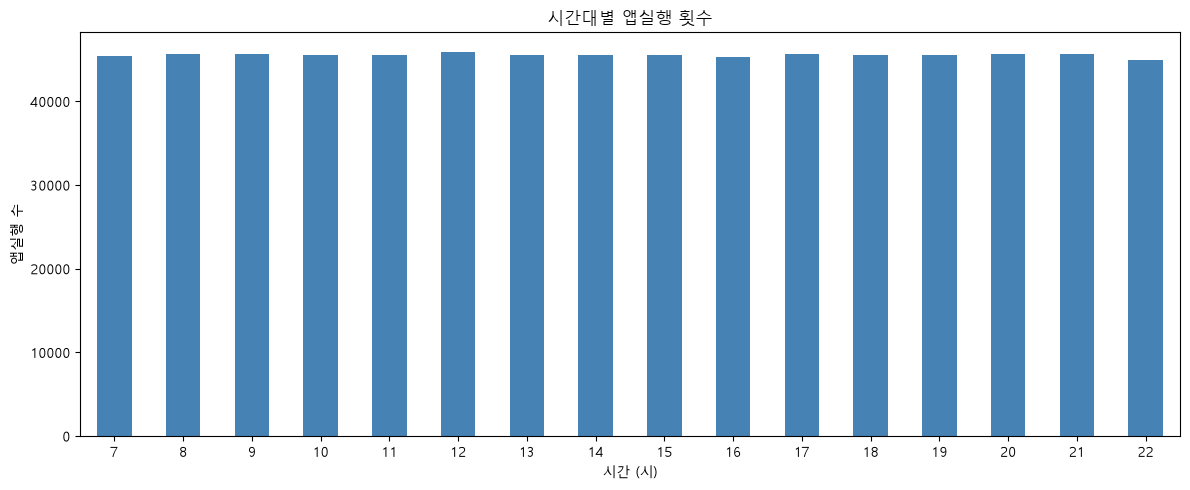

In [70]:
# 시간대별 앱실행 패턴
df['hour'] = df['Event_Time'].dt.hour

hourly = df[df['Event_Type'] == '앱실행'].groupby('hour').size()

plt.figure(figsize=(12, 5))
hourly.plot(kind='bar', color='steelblue')
plt.title('시간대별 앱실행 횟수')
plt.xlabel('시간 (시)')
plt.ylabel('앱실행 수')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

아 이거는 너무 균일해서 패턴이 안보이네...

In [71]:
# 전체 유저 중 온보딩 완료한 유저 비율
total_users = df['User_ID'].nunique()
onboarding_users = df[df['Event_Type'] == '온보딩_완료']['User_ID'].nunique()

print(f"전체 유저: {total_users}명")
print(f"온보딩 완료 유저: {onboarding_users}명")
print(f"온보딩 완료율: {onboarding_users/total_users*100:.1f}%")

전체 유저: 12453명
온보딩 완료 유저: 5719명
온보딩 완료율: 45.9%


오 절반 이상이 온보딩 완료를 못했네..

In [72]:
# 온보딩 완료 유저 vs 미완료 유저 분류
onboarding_done = df[df['Event_Type'] == '온보딩_완료']['User_ID'].unique()

df['온보딩완료'] = df['User_ID'].isin(onboarding_done)

# 그룹별 D30 리텐션
def get_retention(group_df, days):
    users = group_df.groupby('User_ID')['가입일자'].first().reset_index()
    events = group_df[group_df['Event_Type'] == '앱실행'].copy()
    events['days'] = (events['Event_Time'].dt.normalize() - pd.to_datetime(events['가입일자'])).dt.days
    retained = events[events['days'] == days]['User_ID'].nunique()
    return retained / users['User_ID'].nunique() * 100

for group_name, group_df in df.groupby('온보딩완료'):
    label = '온보딩완료' if group_name else '미완료'
    d7 = get_retention(group_df, 7)
    d30 = get_retention(group_df, 30)
    print(f"{label} → D7: {d7:.1f}%, D30: {d30:.1f}%")

미완료 → D7: 39.0%, D30: 20.1%
온보딩완료 → D7: 46.3%, D30: 29.5%


온보딩 완료 여부에 따른 리텐션 차이:
-   구분 | D7 | D30 | 
-  온보딩 완료 | 46.3% | 29.5% | 
-  미완료 | 39.0% | 20.1% | 
-  차이 | +7.3% | +9.4% |

인사이트:

온보딩을 완료한 유저의 D30 리텐션이 미완료 유저보다 1.5배 높아.

온보딩 완료율이 45.9%밖에 안 되니까, 나머지 54.1%를 온보딩으로 끌어들이면 D30 리텐션 개선 여지가 크다.

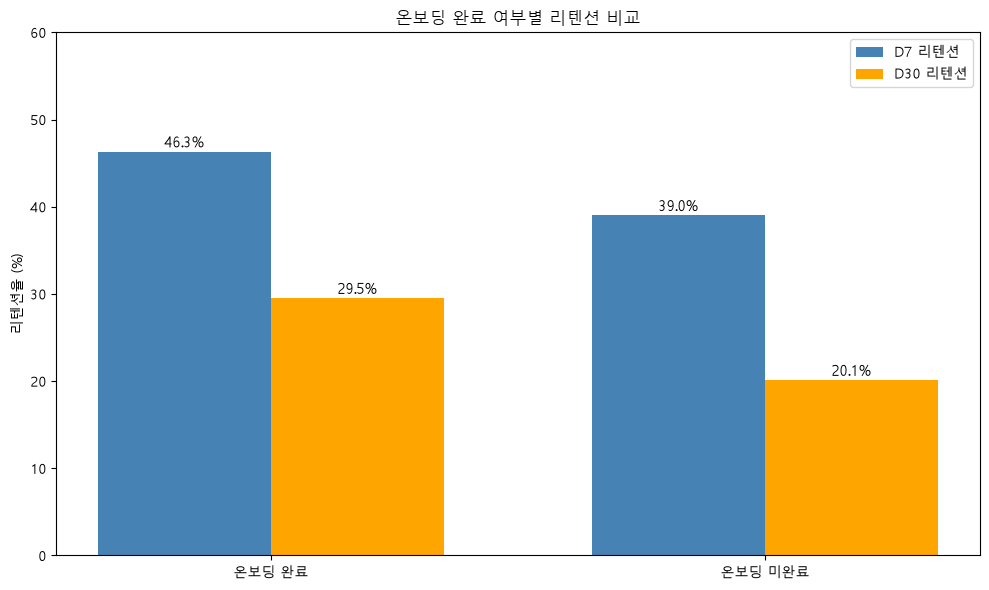

In [73]:
labels = ['온보딩 완료', '온보딩 미완료']
d7_values = [46.3, 39.0]
d30_values = [29.5, 20.1]

x = range(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar([i - width/2 for i in x], d7_values, width, label='D7 리텐션', color='steelblue')
bars2 = ax.bar([i + width/2 for i in x], d30_values, width, label='D30 리텐션', color='orange')

# 수치 표시
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height():.1f}%', ha='center', fontsize=11)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height():.1f}%', ha='center', fontsize=11)

ax.set_title('온보딩 완료 여부별 리텐션 비교')
ax.set_ylabel('리텐션율 (%)')
ax.set_xticks(list(x))
ax.set_xticklabels(labels)
ax.legend()
ax.set_ylim(0, 60)
plt.tight_layout()
plt.show()

## EDA 최종 결과

| # | 발견 | 수치 |
|---|------|------|
| 1 | **2월 유입 폭증** — 광고/오가닉 동반 상승, 외부 바이럴 추정 | 전월 2,100명 → 4,384명 (+109%) |
| 2 | **5월 이후 이벤트 수 하락** — 기존 유저 활동량 감소 시그널 | 14,000건/일 → 하락 추세 |
| 3 | **온보딩 완료율 낮음** — 절반 이상이 온보딩 미완료 | 45.9% (5,719 / 12,453명) |
| 4 | **온보딩이 리텐션 핵심 분기점** — 완료 시 D30 리텐션 1.5배 | 완료 29.5% vs 미완료 20.1% |
| 5 | **앱실행 30회가 이탈 임계점** — 이 구간을 넘기면 헤비유저로 정착 | 31~50회 구간 유저 수 전 구간 중 최소 (808명) |
| 6 | **3/10~14 로그 장애** — 3월 코호트 수치 신뢰도 낮음 | 해당 구간 이벤트 70% 누락 확인 |

---

## 팀원 공유

### 데이터 품질 주의사항
- **3월 코호트 리텐션 수치는 신뢰하면 안 됨**: 3/10~14 로그 장애로 이벤트 약 70% 누락. `is_log_anomaly` 컬럼으로 플래그 처리되어 있으니 3월 분석 시 반드시 필터링 필요.
- **완전 미활동 유저 47명 전원이 3월 가입**: 로그 장애와 연관 가능성 있음. 리텐션 분모를 12,500명으로 쓸 경우 이 47명 포함 여부를 팀 내 통일해야 함.
- **온보딩 완료율 분모 기준 통일 필요**: 전체 가입자 12,500명 기준 45.8% vs 이벤트 발생 유저 12,453명 기준 45.9% — 팀 내 기준 통일 필요.

### 액션 아이템 후보
- **온보딩 퍼널 개선 최우선**: 절반 이상 온보딩 미완료, 완료 시 D30이 1.5배 높음. 어느 단계에서 이탈하는지 추가 분석하면 즉시 개선 포인트 도출 가능.
- **앱실행 11~30회 유저 집중 관리**: 이 구간 유저(3,688명)가 가장 많고 바로 다음 구간(808명)으로 넘어가지 못하고 이탈. 30회 전후 시점에 리텐션 넛지(푸시, 챌린지 추천 등) 실험 검토.
- **2월 코호트 성공 요인 역추적**: 2월 유저 D30 29.1%로 전 기간 최고. 이 유저들의 행동 패턴 분석하면 "무엇이 장기 잔류를 만드는가" 힌트 획득 가능.
- **알림 전략 재검토**: 알림 오픈율 10.9%는 낮은 편. 알림 동의 유저 vs 미동의 유저 리텐션 차이 비교로 알림 효과 검증 필요.

### 전처리된 데이터 파일
- **`data/user_preprocessed.csv`**: 전처리 완료 통합 데이터 (1,730,806행 × 11컬럼). 이후 분석은 이 파일 사용 권장.
  - `is_log_anomaly` 컬럼 포함 (3월 로그 장애 구간 플래그)
  - 모든 결측치 공유하고 처리